In [212]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial

In [213]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [214]:
linestyles = {
    "RV": "-",
    "DC": "--",
    "QAP": "-.",
    "CVM": ":",
}

colors = {
    "DC": "#4285F4",  # Blue
    "CCA": "#EA4335",  # Red
    "AC_1": "#38761D",  # Dark Green
    "AC_sqrt": "#6AA84F",  # Light Green
    "AC_max": "#673AB7",  # Purple
    "RV": "#FBBC05",  # Yellow
}

marker_map = {"DC": "x", "CCA": "o", "AC_1": "D", "AC_sqrt": "D", "AC_max": "D", "RV": "v"}

plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [215]:
results1 = pd.read_csv("simulation_results_20260625_2237.csv")

In [216]:
results1.iloc[2]['args']

"{'setup': (functools.partial(<class 'src.dgp.GaussianNetwork'>, latent_sim='square', sim_kwargs={'noise': True}), <function ASE at 0x14aa3ea56840>), 'method': functools.partial(<class 'src.methods.rv_test.RVTest'>, permutation_type='latent', approximation='permutation'), 'n': 100, 'k': 1, 'alpha': 0.05, 'edge_var': 3, 'npermutations': 200, 'df': 3, 'make_sparse': True, 'sparsity_bias': 1, 'use_true_latent_x': True, 'use_true_latent_z': True, 'rng': Generator(PCG64) at 0x14AA2F5FACE0, 'solver': <function ASE at 0x14aa3ea56840>, 'dgp_name': 'GaussianNetwork_HyppoSim_square', 'method_name': 'RV_PermutationTest_latent'}"

In [217]:
results_concat = results1.copy()

In [218]:
import re


def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # extract method class specifically from the 'method' field (not globally)
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)

        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split(".")[-1]

        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

        mm = re.search(r"\bM\s*=\s*([^,\)]+)", method_val)
        if mm:
            pairs["NN_number"] = mm.group(1).strip()
        coeff = re.search(r"\baggregate_coeff\s*=\s*([^,\)]+)", method_val)
        if coeff:
            pairs["aggregate"] = coeff.group(1).strip()

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    copula_match = re.search(r"copula_model='([^']+)'", s)
    pairs["copula_model"] = copula_match.group(1) if copula_match else "NA"

    latent_sim_match = re.search(r"\blatent_sim='([^']+)'", s)
    pairs["latent_sim"] = latent_sim_match.group(1) if latent_sim_match else "NA"

    # extract solver: handle both plain string and <function Name at 0x...>
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)

    # extract degree
    pairs["degree"] = (
        re.search(r"degree=(\d+)", s).group(1)
        if re.search(r"degree=(\d+)", s)
        else "NA"
    )

    return pairs

In [219]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [220]:
results = results_concat.copy()
results["args"] = results["args"].apply(parse_config_string)

In [222]:
results["ComputeAll"] = results["ComputeAll"].apply(parse_result_string)

In [223]:
results["density"] = results["density"].apply(
    lambda x: re.findall(r"np\.float64\((.*?)\)", x)
)
results["density_A"] = results["density"].apply(lambda x: x[0])
results["density_B"] = results["density"].apply(lambda x: x[1])

In [224]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results["n"] = results["args"].apply(lambda x: x.get("n", "NA"))
results["k"] = results["args"].apply(lambda x: x.get("k", "NA"))
results["method"] = results["args"].apply(lambda x: x.get("method", "NA").strip("'"))
results["solver"] = results["args"].apply(lambda x: x.get("solver", "NA").strip("'"))
results['make_sparse'] = results["args"].apply(lambda x: x.get("make_sparse", "NA"))
results["use_true_x"] = results["args"].apply(
    lambda x: x.get("use_true_latent_x", "NA")
)
results["use_true_z"] = results["args"].apply(
    lambda x: x.get("use_true_latent_z", "NA")
)
results["latent_sim"] = results["args"].apply(
    lambda x: x.get("latent_sim", "NA").strip("'")
)

results["aggregate"] = results["args"].apply(
    lambda x: x.get("aggregate", "NA").replace("np.float64(", "").replace(")", "")
)

results["copula"] = results["args"].apply(
    lambda x: x.get("copula_model", "NA").strip("'")
)
results["dgp_name"] = results["args"].apply(
    lambda x: x.get("dgp_name", "NA").strip("'")
)
results["marginals"] = results["args"].apply(
    lambda x: x.get("marginals", "NA").strip("'")
)
results["rho"] = results["args"].apply(
    lambda x: x.get("rho", "NA").replace("np.float64(", "").replace(")", "")
)
results["rho"] = results["rho"].apply(lambda x: float(x) if x != "NA" else np.nan)
results["degree"] = results["args"].apply(
    lambda x: x.get("degree", "NA").replace("np.int64(", "").replace(")", "")
)
results["NN_number"] = results["args"].apply(
    lambda x: x.get("NN_number", "NA").replace("np.int64(", "").replace(")", "")
)

In [225]:
results["n"] = results["n"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)
results["k"] = results["k"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)

In [226]:
results["dgp"] = results["args"].apply(lambda x: x.get("dgp_name", "NA"))
results["dgp_name"] = [x.split("_")[0].strip("'") for x in results["dgp"]]
# results_all["copula"] = [x.split("_")[2].strip("'") for x in results_all["dgp"]]

In [227]:
results["RelativeFrobeniusNorm_x"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results["RelativeFrobeniusNorm_z"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results["ProcrustesDistance_x"] = results["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_x", np.nan)
)
results["ProcrustesDistance_z"] = results["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_z", np.nan)
)

results["FalseRejection"] = results["ComputeAll"].apply(
    lambda x: x["FalseRejection"]
)
results["TrueRejection"] = results["ComputeAll"].apply(
    lambda x: x["TrueRejection"]
)
results["Rejection"] = results["ComputeAll"].apply(lambda x: x["Rejection"])

In [228]:
results["avg_rel_frob_z"] = results.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["RelativeFrobeniusNorm_z"].transform("mean")

results["avg_proc_dist_z"] = results.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["ProcrustesDistance_z"].transform("mean")

In [229]:
results["permutation_type"] = results["RelativeFrobeniusNorm_z"].apply(
    lambda x: "observed" if np.isnan(x) else "latent"
)

results["marginals"] = results["marginals"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results.rename(columns={"TrueRejection": "Power"}, inplace=True)

In [230]:
results_all = results.copy()

In [231]:
temp = results_all[results_all["NN_number"] != "NA"].copy()
temp['NN_number'] = temp['NN_number'].str.replace("'sqrt'", 'sqrt')
temp["method"] = temp["method"] + "_" + temp["NN_number"]
results_all[results_all["NN_number"] != "NA"] = temp

results_all['aggregate'] = results_all['aggregate'].replace("None", 'NA')
temp = results_all[results_all["aggregate"] != "NA"].copy()
temp['aggregate'] = temp['aggregate'].str.replace("'max'", 'max')
temp["method"] = temp["method"] + "_" + temp["aggregate"]
results_all[results_all["aggregate"] != "NA"] = temp

In [232]:
results_all["method"] = results_all["method"].replace(
    {
        "DistanceCorrelationTest": "DC",
        "RVTest": "RV",
        "ObservedCVM": "CVM",
        "CanonicalCorrelationTest": "CCA",
        "MultivariateACTest_sqrt": "AC_sqrt",
        "MultivariateACTest_1": "AC_1",
        "MultivariateACTest_sqrt_max": "AC_max"
    }
)

In [233]:
results_all["latent_sim"] = results_all["latent_sim"].replace(
    {
        "multiplicative_noise": "mult_noise",
        "uncorrelated_bernoulli": "bernoulli",
        "joint_normal": "normal",
        "logarithmic": "log",
    }
)

In [234]:
# results_all = results_all[results_all["edge_var"] == "3"]
# results_all = results_all[~results_all["degree"].isin(["1", "3"])]

### Defining different aggregations

In [235]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [236]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [237]:
# agg_null_gaussian = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_bernoulli = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_frob = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_frob = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_proc = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_proc = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )

In [238]:
rcparams = {
    "text.usetex": False,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",  # Bolds axis labels (x, y)
    "axes.titleweight": "normal",  # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

In [239]:
# temp = agg_null_gaussian.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals"],
#     height=2,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted Network",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=False,
#     show_col_names=False,
#     col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
# )

In [240]:
# temp = agg_null_bernoulli.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals", "permutation_type"],
#     height=2,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Binary Network",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=False,
#     show_col_names=False,
#     col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
# )

### Power

In [ ]:
agg_alt_gaussian = aggregate_results(
    results_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginals", "method", "latent_sim", "use_true_z", "make_sparse"],
)

agg_alt_bernoulli = aggregate_results(
    results_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginals", "method", "latent_sim", "use_true_z", "make_sparse"],
)

agg_alt_gaussian_copula = aggregate_results(
    results_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginals", "method", "copula", "use_true_z"],
)
agg_alt_bernoulli_copula = aggregate_results(
    results_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginals", "method", "copula", "use_true_z"],
)
# agg_alt_02_gaussian_frob = aggregate_results(
#     results_alt_02_gaussian,
#     y_axis="Power",
#     x_axis="avg_rel_frob_z",
#     factors=["marginals", "method", "latent_sim", "use_true_z"],
# )

# agg_alt_02_bernoulli_frob = aggregate_results(
#     results_alt_02_bernoulli,
#     y_axis="Power",
#     x_axis="avg_rel_frob_z",
#     factors=["marginals", "method", "latent_sim", "use_true_z"],
# )

In [242]:
# temp = agg_alt_gaussian_copula.copy()
# temp = temp[(temp["use_true_z"] == "False") & (temp["n"] == 300)]
# # temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plot_scatter_markers,
#     x_axis="marginals",
#     y_axis="Rejection_mean",
#     factors=["method", "copula"],
#     height=3,
#     aspect=1.5,
#     colors=colors,
#     markers=marker_map,
#     add_legend=True,
#     title="",
#     show_x_axis_title=False,
#     x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=15,  # ← same for y (optional)
#     x_tick_rotation=0,
#     # x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
#     # col_order=["gaussian", "clayton", "gumbel", "mixture_uniform"],
# )

In [243]:
# temp = agg_alt_gaussian.copy()
# temp = temp[temp["n"] == 300]
# temp = temp[temp["use_true_z"] == "True"]

# first_batch = [
#     "linear",
#     "exponential",
#     "cubic",
#     "step",
#     "circle",
#     "ellipse",
#     "spiral",
#     "quadratic",
# ]
# second_batch = [
#     "fourth_root",
#     "log",
#     "w_shaped",
#     "two_parabolas",
#     "bernoulli",
#     "square",
#     "diamond",
#     "independence",
# ]

# plot_grid(
#     grouped_stats=temp[temp["latent_sim"].isin(first_batch)],
#     x_axis="latent_sim",
#     y_axis="Rejection_mean",
#     factors=["method", "n"],
#     plotting_function=plot_scatter_markers,
#     colors=colors,
#     markers=marker_map,
#     height=3,
#     aspect=3,
#     add_legend=True,
#     x_order=first_batch,
#     show_x_axis_title=False,
#     x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=17,  # ← same for y (optional)
#     x_tick_rotation=0,
#     title="",
# )

# plot_grid(
#     grouped_stats=temp[~temp["latent_sim"].isin(first_batch)],
#     x_axis="latent_sim",
#     y_axis="Rejection_mean",
#     factors=["method", "n"],
#     plotting_function=plot_scatter_markers,
#     colors=colors,
#     markers=marker_map,
#     height=3,
#     aspect=3,
#     add_legend=True,
#     # x_order=second_batch,
#     show_x_axis_title=False,
#     x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=17,  # ← same for y (optional)
#     x_tick_rotation=0,
#     title="",
# )

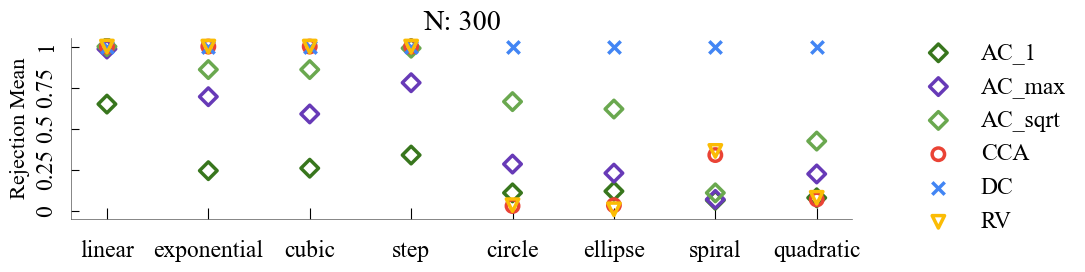

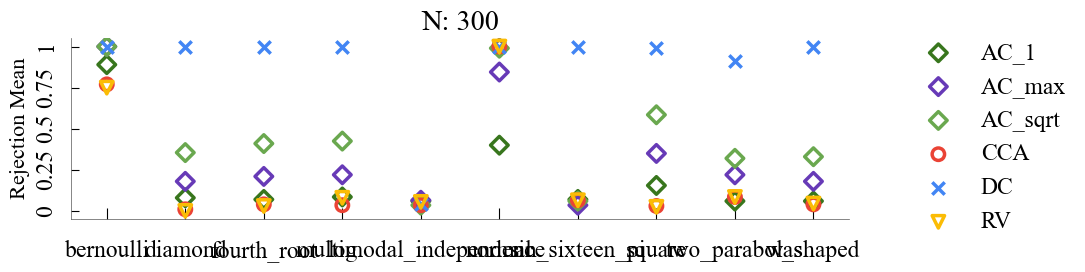

In [244]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp["n"] == 300]
temp = temp[temp["use_true_z"] == "False"]

first_batch = [
    "linear",
    "exponential",
    "cubic",
    "step",
    "circle",
    "ellipse",
    "spiral",
    "quadratic",
]
second_batch = [
    "fourth_root",
    "log",
    "w_shaped",
    "two_parabolas",
    "bernoulli",
    "square",
    "diamond",
    "independence",
]

plot_grid(
    grouped_stats=temp[temp["latent_sim"].isin(first_batch)],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3,
    aspect=3,
    add_legend=True,
    x_order=first_batch,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="",
)

plot_grid(
    grouped_stats=temp[~temp["latent_sim"].isin(first_batch)],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3,
    aspect=3,
    add_legend=True,
    # x_order=second_batch,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="",
)

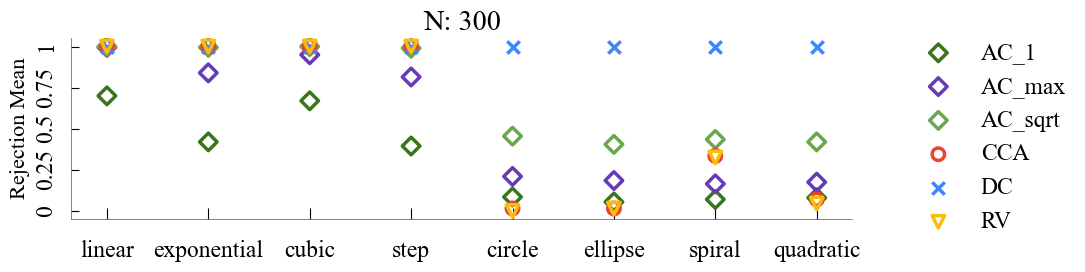

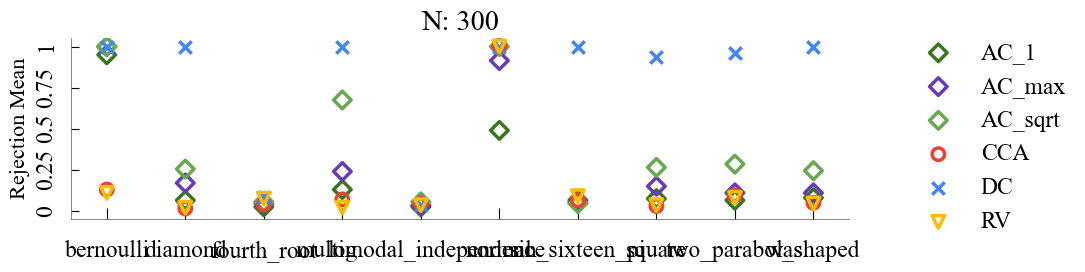

In [245]:
temp = agg_alt_gaussian.copy()
temp = temp[temp["n"] == 300]
temp = temp[temp["use_true_z"] == "False"]

first_batch = [
    "linear",
    "exponential",
    "cubic",
    "step",
    "circle",
    "ellipse",
    "spiral",
    "quadratic",
]
second_batch = [
    "fourth_root",
    "log",
    "w_shaped",
    "two_parabolas",
    "bernoulli",
    "square",
    "diamond",
    "independence",
]

plot_grid(
    grouped_stats=temp[temp["latent_sim"].isin(first_batch)],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3,
    aspect=3,
    add_legend=True,
    x_order=first_batch,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="",
)

plot_grid(
    grouped_stats=temp[~temp["latent_sim"].isin(first_batch)],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3,
    aspect=3,
    add_legend=True,
    # x_order=second_batch,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="",
)

In [246]:
# temp = agg_alt_02_gaussian.copy()
# temp = temp[~temp['copula'].isin(['gumbel'])]
# temp = temp[temp['n']==200]
# temp.iloc[:, temp.columns.get_loc('method')] = temp['method'].replace({'DistanceCorrelation':'DC', 'ObservedCVM':'CVM', 'RVPermutationTest':'RV'})

# plot_grid(
#     grouped_stats=temp[temp['copula'].isin(['clayton', 'gaussian'])],
#     plotting_function=plot_heatmap,
#     x_axis="marginals",
#     y_axis="Power_mean",
#     factors=["method", "copula"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Weighted network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)', 'marginals':''},
#     show_row_names=False
# )

# plot_grid(
#     grouped_stats=temp[~temp['copula'].isin(['clayton', 'gaussian'])],
#     plotting_function=plot_heatmap,
#     x_axis="marginals",
#     y_axis="Power_mean",
#     factors=["method", "copula"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Weighted network - n=200",
#     name_conversion={'n':'n (Number of nodes)', 'marginals':''},
#     show_row_names=False
# )

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)'},
#     save_path="figures/power_weighted_02_light_tails"
# )

In [247]:
temp = agg_alt_02_gaussian.copy()
group1 = ["gumbel", "clayton", "gaussian"]
temp = temp[temp["n"] == 100]
# temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp[temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["gaussian", "clayton", "gumbel"],
)

# plot_grid(
#     grouped_stats=temp[temp['copula'].isin(group1)],
#     plotting_function=plot_scatter_markers,
#     x_axis="marginals",
#     y_axis="Power_mean",
#     factors=["method", 'copula'],
#     height=3,
#     aspect=1.5,
#     colors=colors,
#     markers=marker_map,
#     add_legend=False,
#     title="",
#     show_x_axis_title=False,
#     x_tick_labelsize=15,       # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=15,       # ← same for y (optional)
#     x_tick_rotation=0,
#     x_order = ['gaussian', 't df=5', 'chi df=5', 'unif(-1, 1)', 'cauchy'],
#     col_order = ['gaussian', 'clayton', 'gumbel'],
#     save_path='figures/power_weighted_part_1'
# )

plot_grid(
    grouped_stats=temp[~temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["student", "mixture"],
)


# plot_grid(
#     grouped_stats=temp[~temp['copula'].isin(group1)],
#     plotting_function=plot_scatter_markers,
#     x_axis="marginals",
#     y_axis="Power_mean",
#     factors=["method", 'copula'],
#     height=3,
#     aspect=1.5,
#     colors=colors,
#     markers=marker_map,
#     title="",
#     show_x_axis_title=False,
#     x_tick_labelsize=15,       # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=15,       # ← same for y (optional)
#     x_tick_rotation=0,
#     x_order = ['gaussian', 't df=5', 'chi df=5', 'unif(-1, 1)', 'cauchy'],
#     col_order = ['student', 'mixture'],
#     save_path='figures/power_weighted_part_2'
# )

NameError: name 'agg_alt_02_gaussian' is not defined

In [ ]:
# heavy tails

# temp = agg_alt_02_gaussian.copy()
# temp = temp[temp['copula'].isin(['gumbel', 'clayton', 'gaussian'])]

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "marginals", "copula"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)', 'marginals':'', 'copula':''}
# )

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=True,
#     title="",
#     save_path="figures/power_weighted_02_heavy_tails"
# )

KeyError: 'Power_mean'

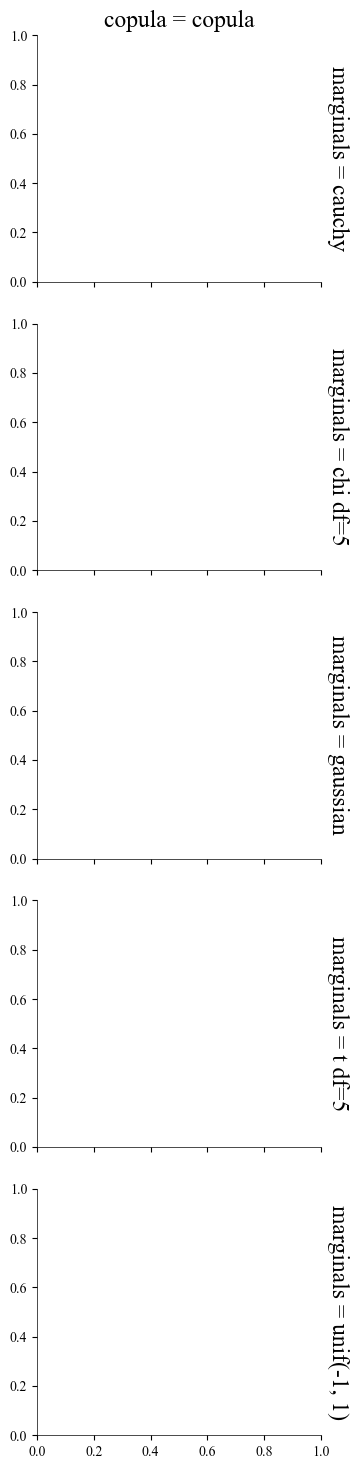

In [ ]:
temp = agg_alt_02_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

In [ ]:
# --- 2. QUANTIFYING SENSITIVITY ---
# Group by the factors that SHOULD keep power constant
grouped = agg_alt_02_gaussian.groupby(["n", "copula", "method"])["Power_mean"]

# Calculate the max-min range of power across the marginals
sensitivity_df = grouped.agg(
    power_range=lambda x: x.max() - x.min(), power_std="std"
).reset_index()

# Find the overall sensitivity per method
method_ranking = (
    sensitivity_df.groupby("method")[["power_range", "power_std"]]
    .mean()
    .sort_values("power_range")
)

print("Methods sorted by sensitivity to marginals (Lowest = Most Invariant):")
print(method_ranking)

Methods sorted by sensitivity to marginals (Lowest = Most Invariant):
        power_range  power_std
method                        
RV         0.520000   0.218342
DC         0.532000   0.217870
CVM        0.588000   0.265886
QAP        0.669333   0.278752


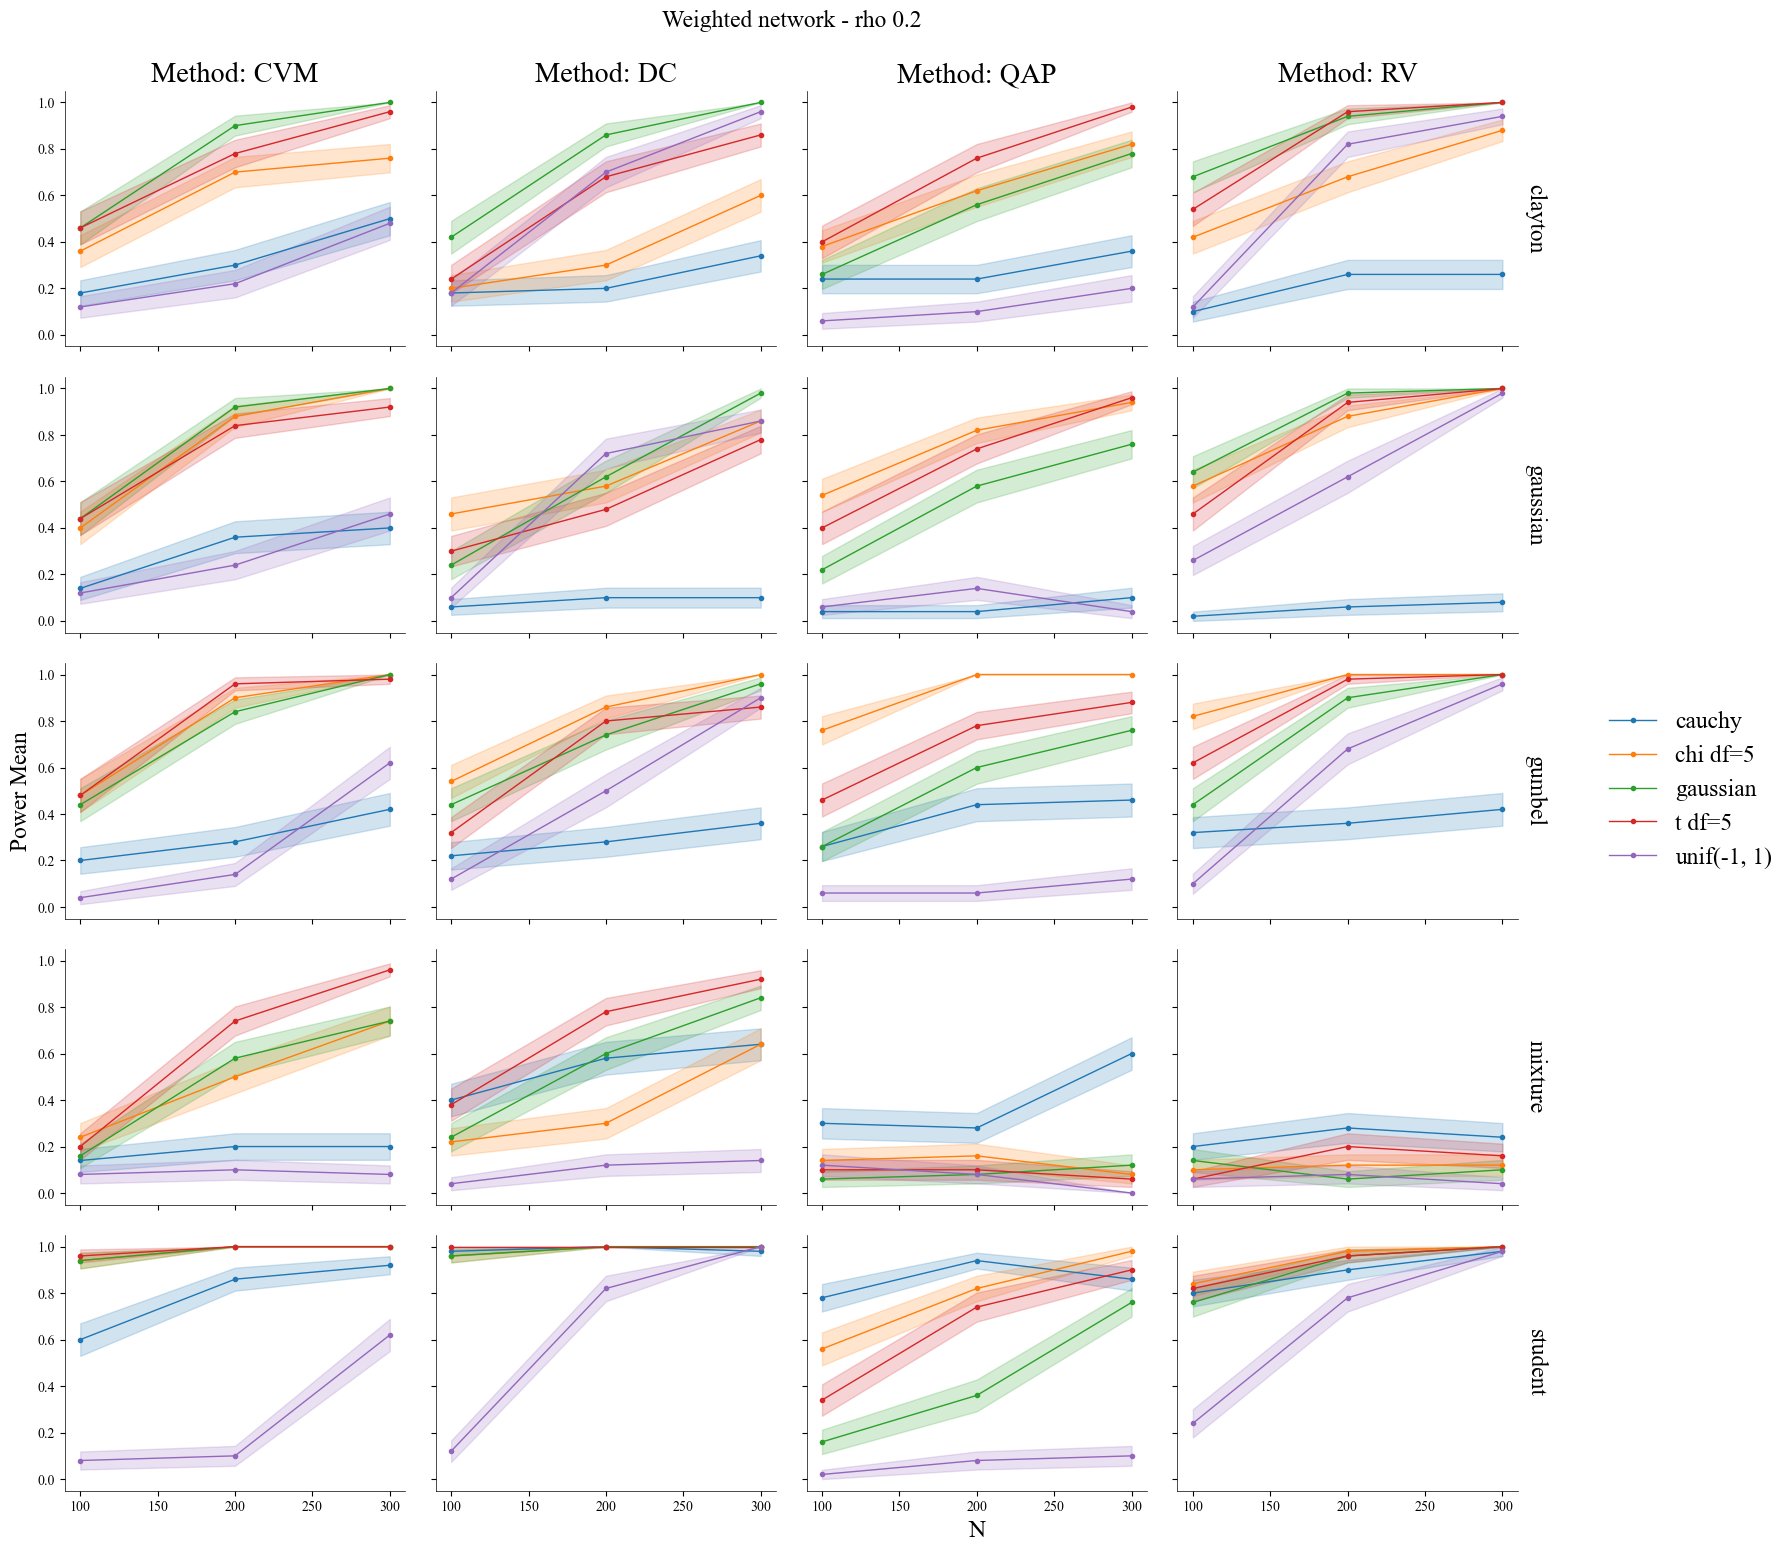

In [ ]:
temp = agg_alt_02_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["marginals", "method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=True,
    title="Weighted network - rho 0.2",
    show_row_names=False,
)

flipping


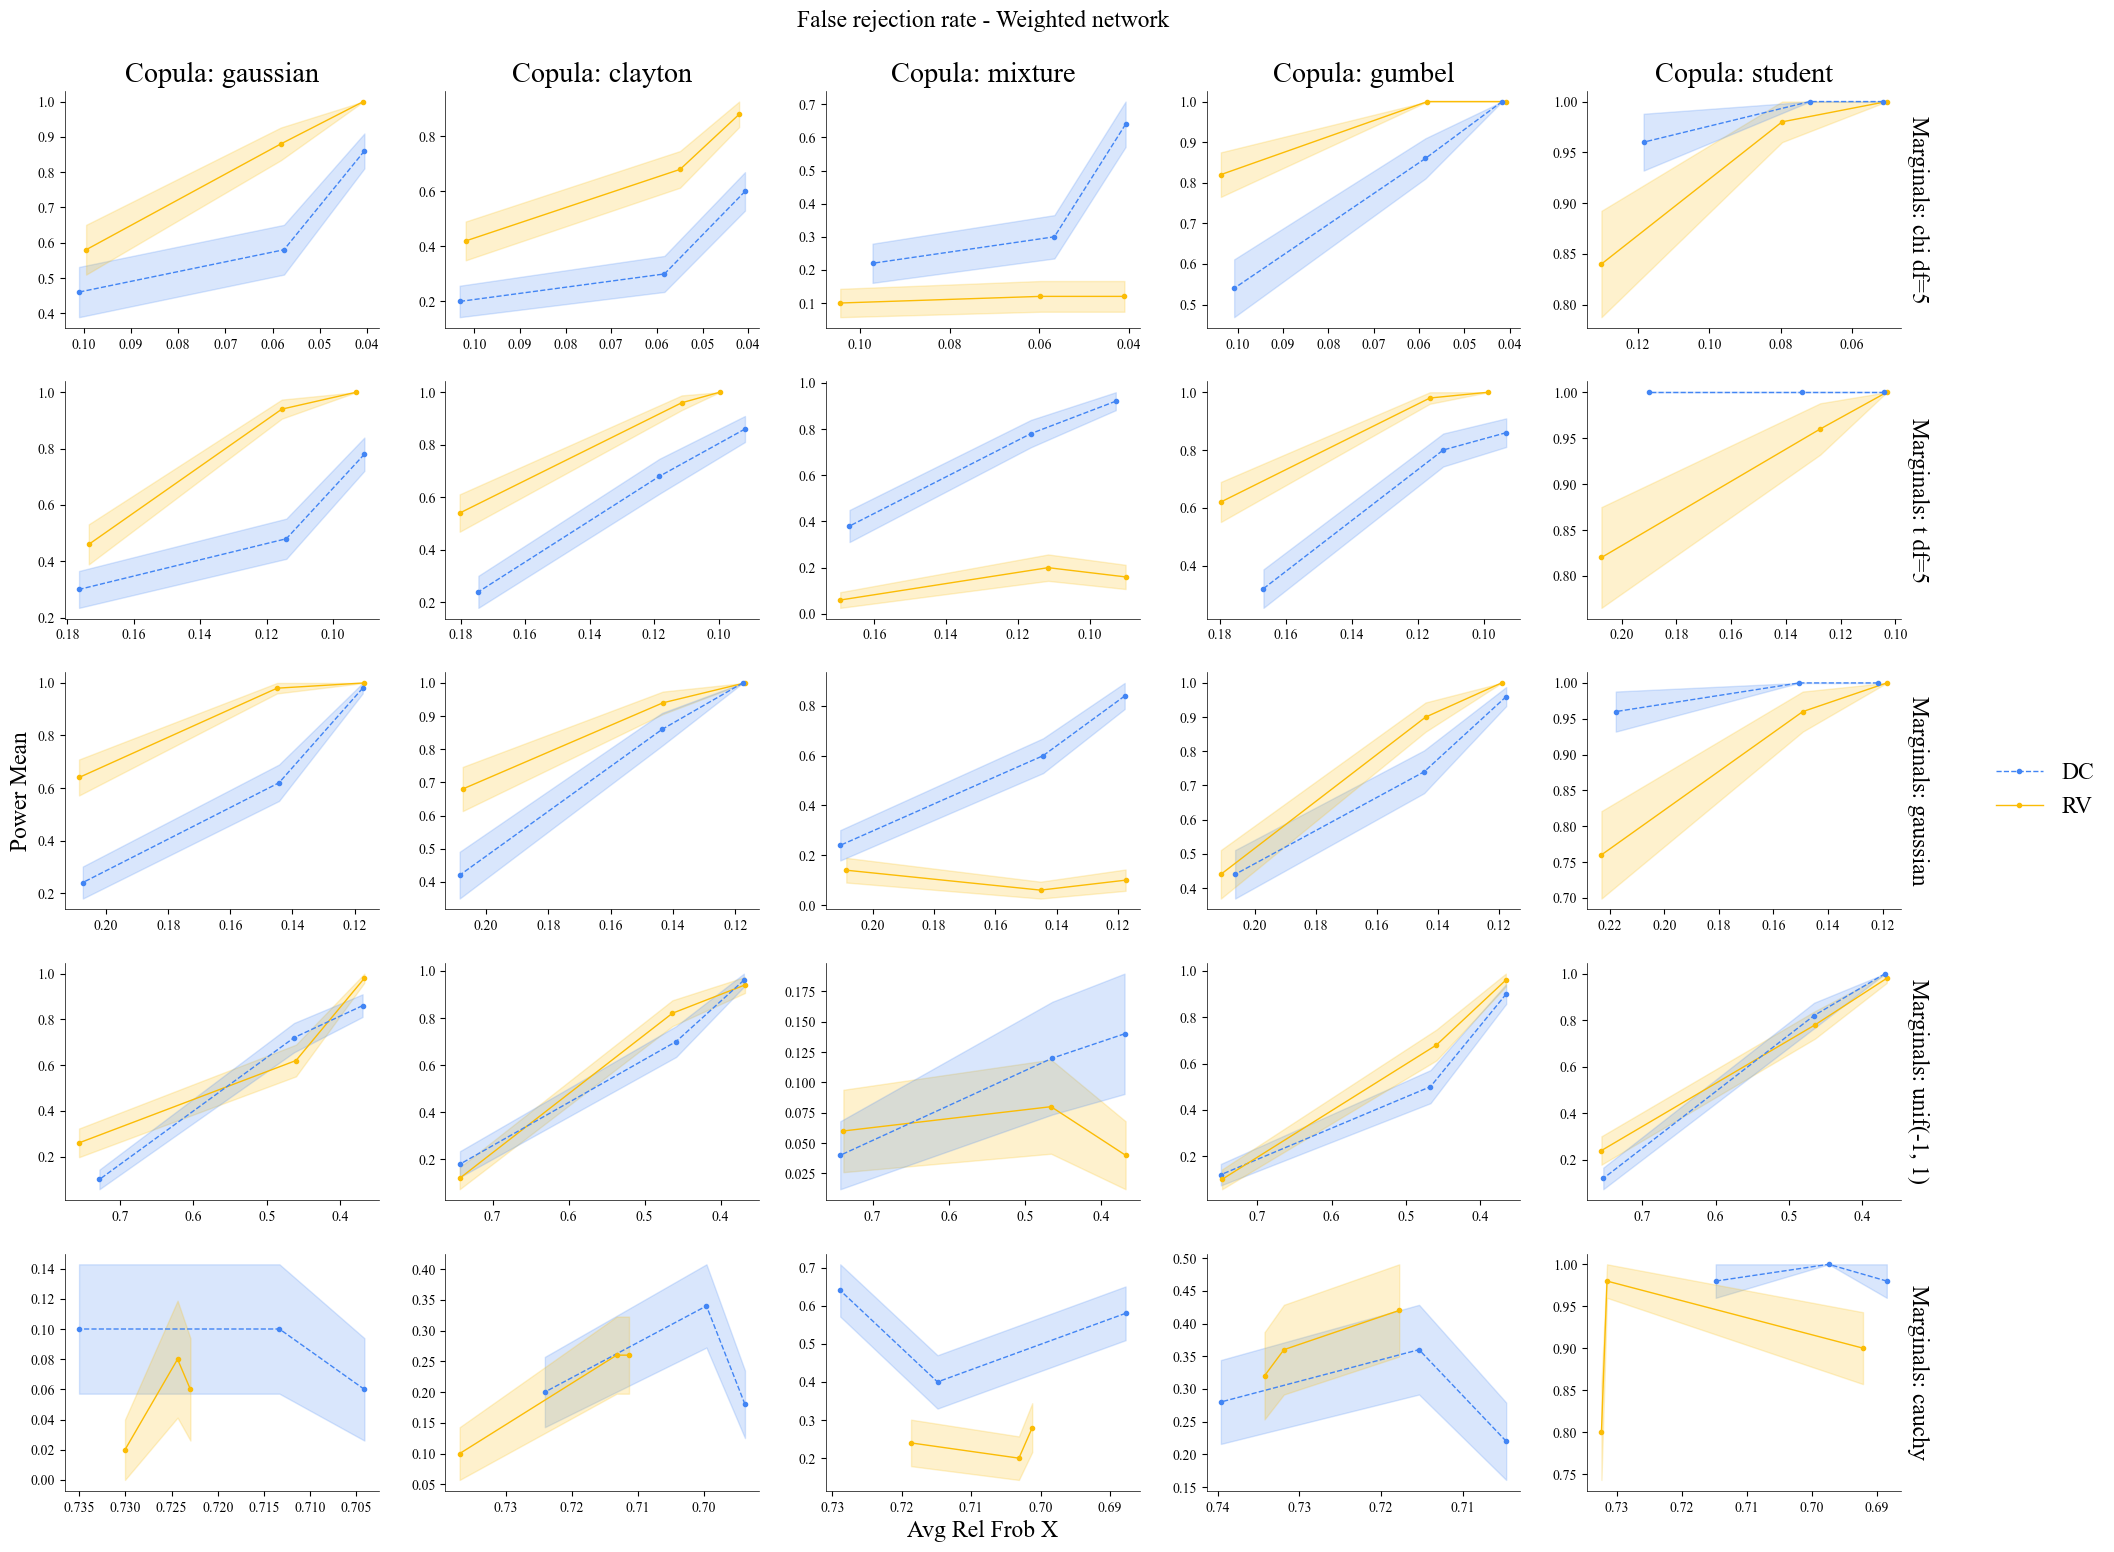

In [ ]:
temp = agg_alt_02_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

### Binary network

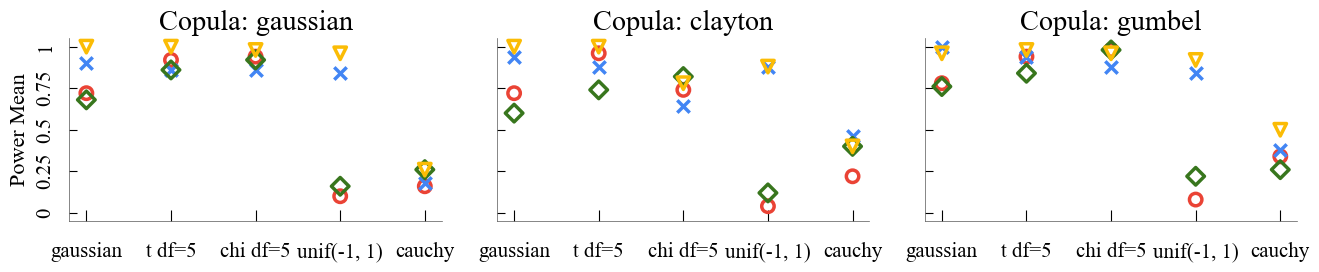

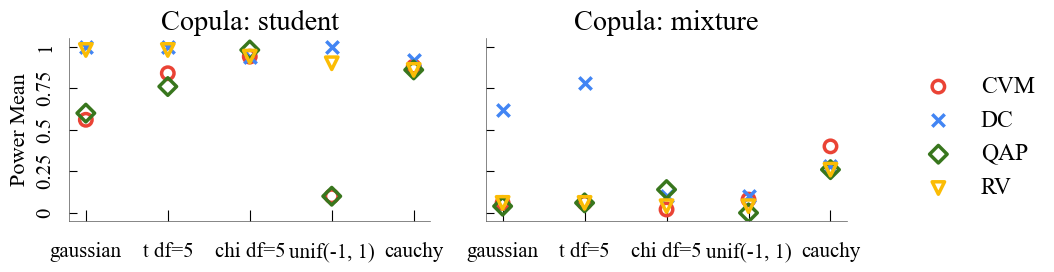

In [ ]:
temp = agg_alt_02_bernoulli.copy()
group1 = ["gumbel", "clayton", "gaussian"]
temp = temp[temp["n"] == 300]
temp["setup"] = temp["copula"] + "_" + temp["marginals"]
# temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp[temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["gaussian", "clayton", "gumbel"],
)

plot_grid(
    grouped_stats=temp[temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["gaussian", "clayton", "gumbel"],
    save_path="figures/power_binary_part_1",
)

plot_grid(
    grouped_stats=temp[~temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["student", "mixture"],
)


plot_grid(
    grouped_stats=temp[~temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["student", "mixture"],
    save_path="figures/power_binary_part_2",
)

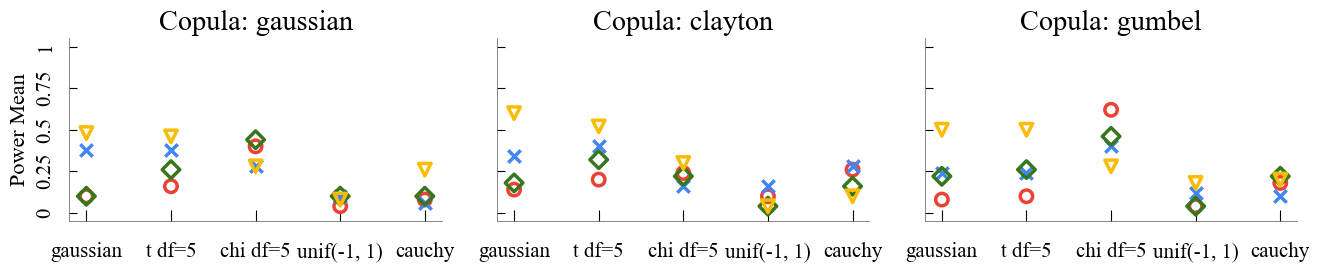

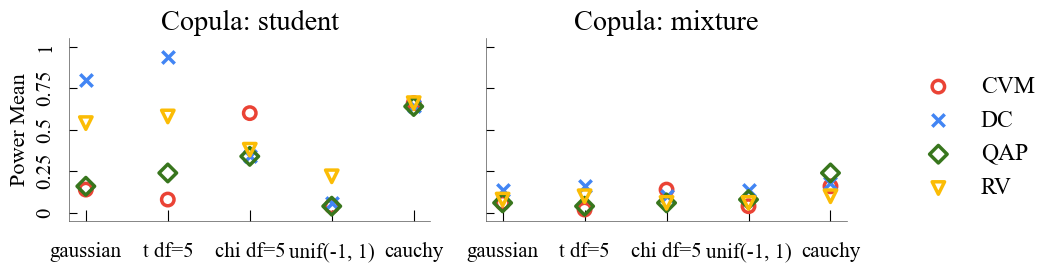

In [ ]:
temp = agg_alt_02_bernoulli.copy()
group1 = ["gumbel", "clayton", "gaussian"]
temp = temp[temp["n"] == 100]
temp["setup"] = temp["copula"] + "_" + temp["marginals"]
# temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp[temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["gaussian", "clayton", "gumbel"],
)

# plot_grid(
#     grouped_stats=temp[temp['copula'].isin(group1)],
#     plotting_function=plot_scatter_markers,
#     x_axis="marginals",
#     y_axis="Power_mean",
#     factors=["method", 'copula'],
#     height=3,
#     aspect=1.5,
#     colors=colors,
#     markers=marker_map,
#     add_legend=False,
#     title="",
#     show_x_axis_title=False,
#     x_tick_labelsize=15,       # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=15,       # ← same for y (optional)
#     x_tick_rotation=0,
#     x_order = ['gaussian', 't df=5', 'chi df=5', 'unif(-1, 1)', 'cauchy'],
#     col_order = ['gaussian', 'clayton', 'gumbel'],
#     save_path='figures/power_binary_part_1'
# )

plot_grid(
    grouped_stats=temp[~temp["copula"].isin(group1)],
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    col_order=["student", "mixture"],
)


# plot_grid(
#     grouped_stats=temp[~temp['copula'].isin(group1)],
#     plotting_function=plot_scatter_markers,
#     x_axis="marginals",
#     y_axis="Power_mean",
#     factors=["method", 'copula'],
#     height=3,
#     aspect=1.5,
#     colors=colors,
#     markers=marker_map,
#     title="",
#     show_x_axis_title=False,
#     x_tick_labelsize=15,       # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=15,       # ← same for y (optional)
#     x_tick_rotation=0,
#     x_order = ['gaussian', 't df=5', 'chi df=5', 'unif(-1, 1)', 'cauchy'],
#     col_order = ['student', 'mixture'],
#     save_path='figures/power_binary_part_2'
# )

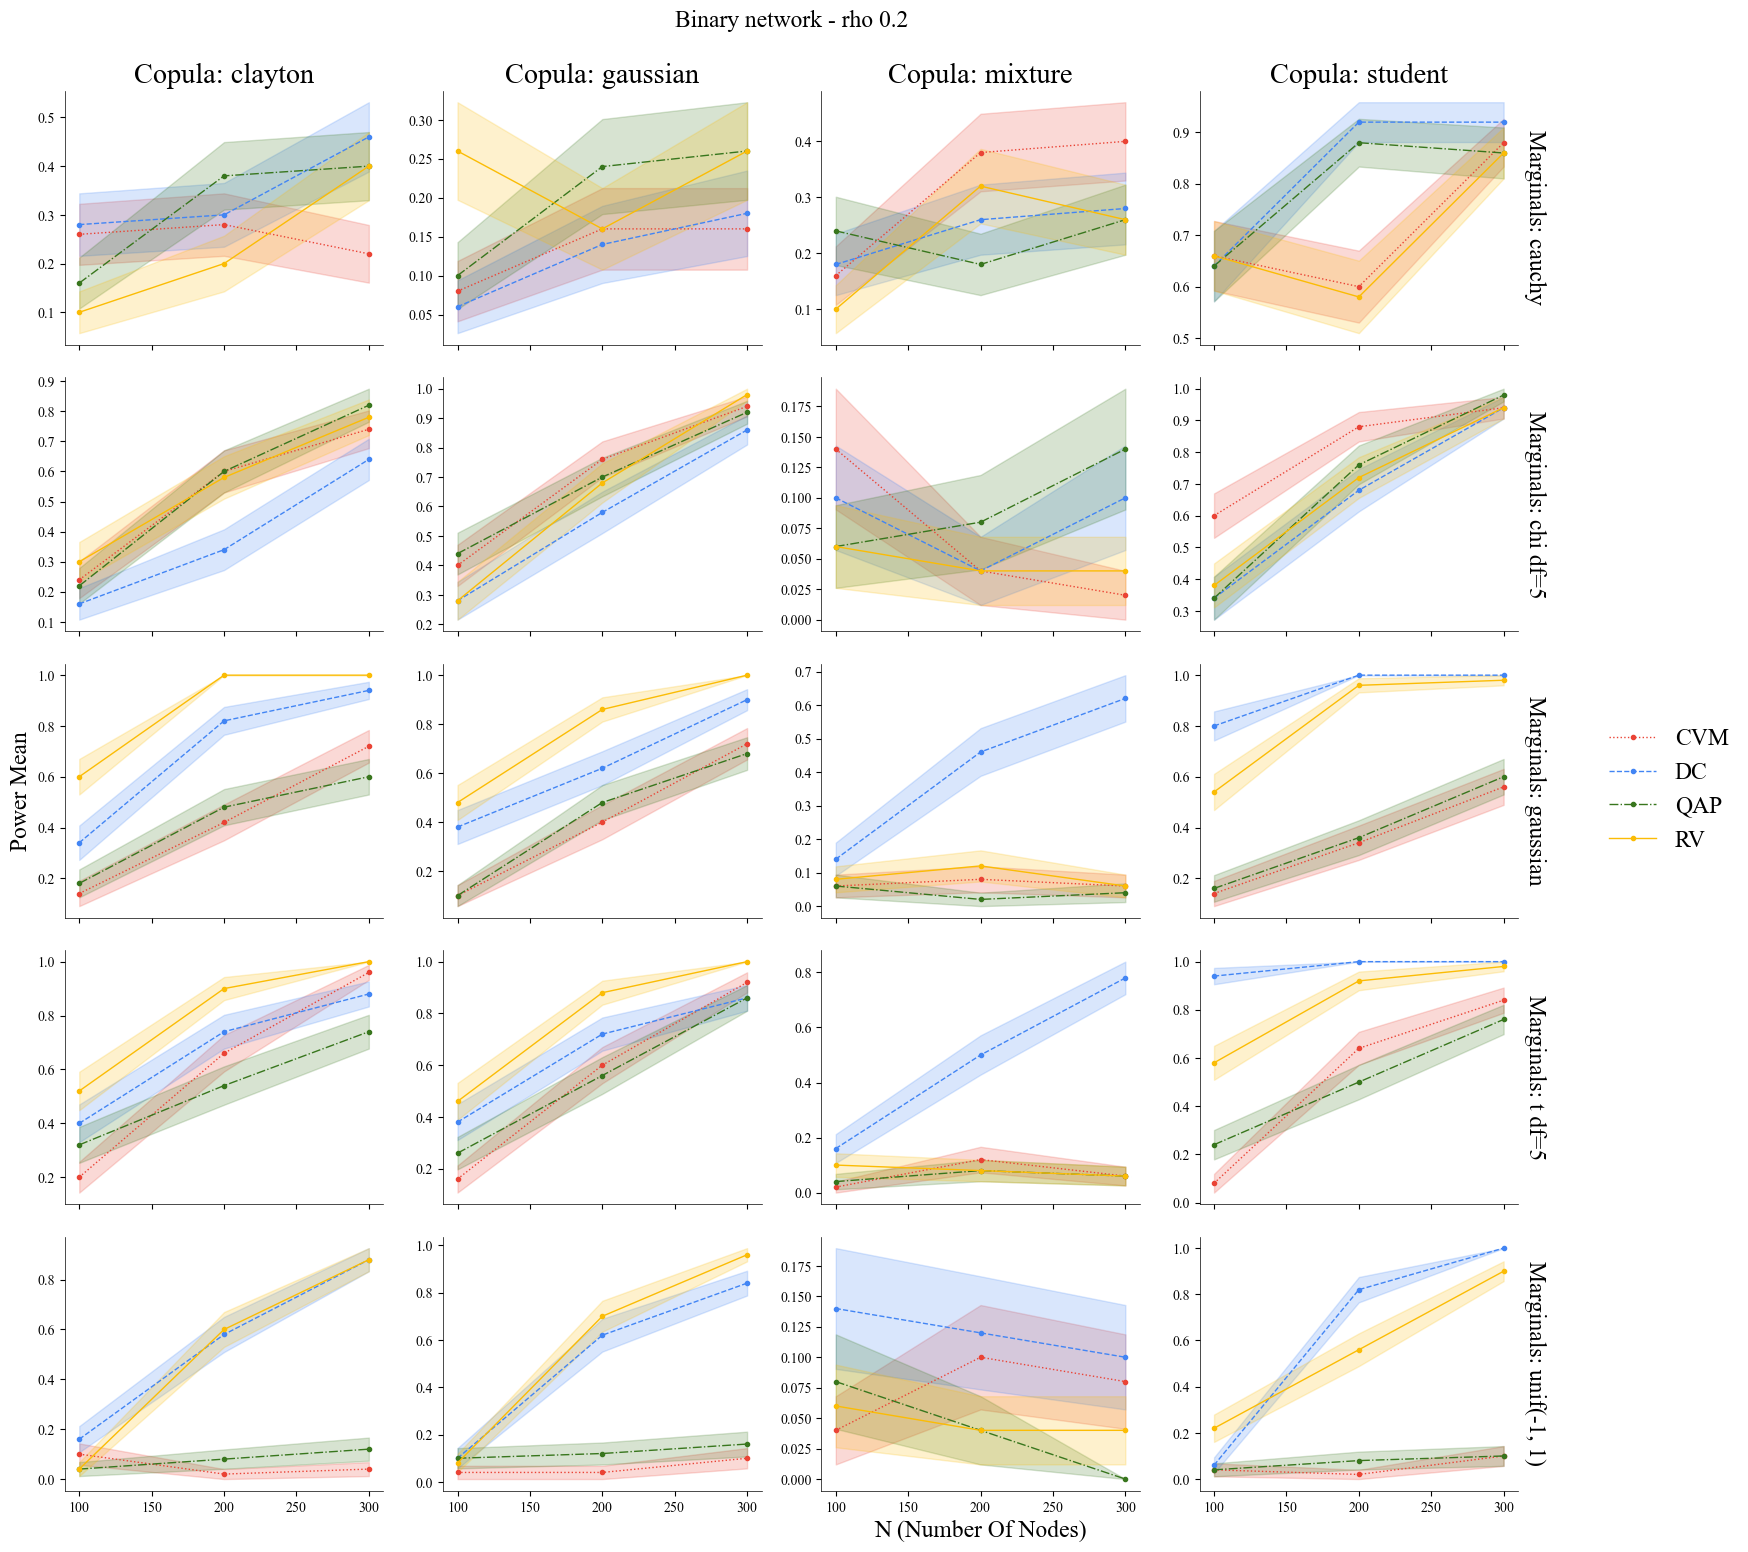

In [ ]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp["copula"].isin(["gumbel"])]
# temp = temp[temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
    name_conversion={"n": "n (Number of nodes)"},
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Binary network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)'},
#     save_path="figures/binary_network_rho_0_2_light_tails"
# )

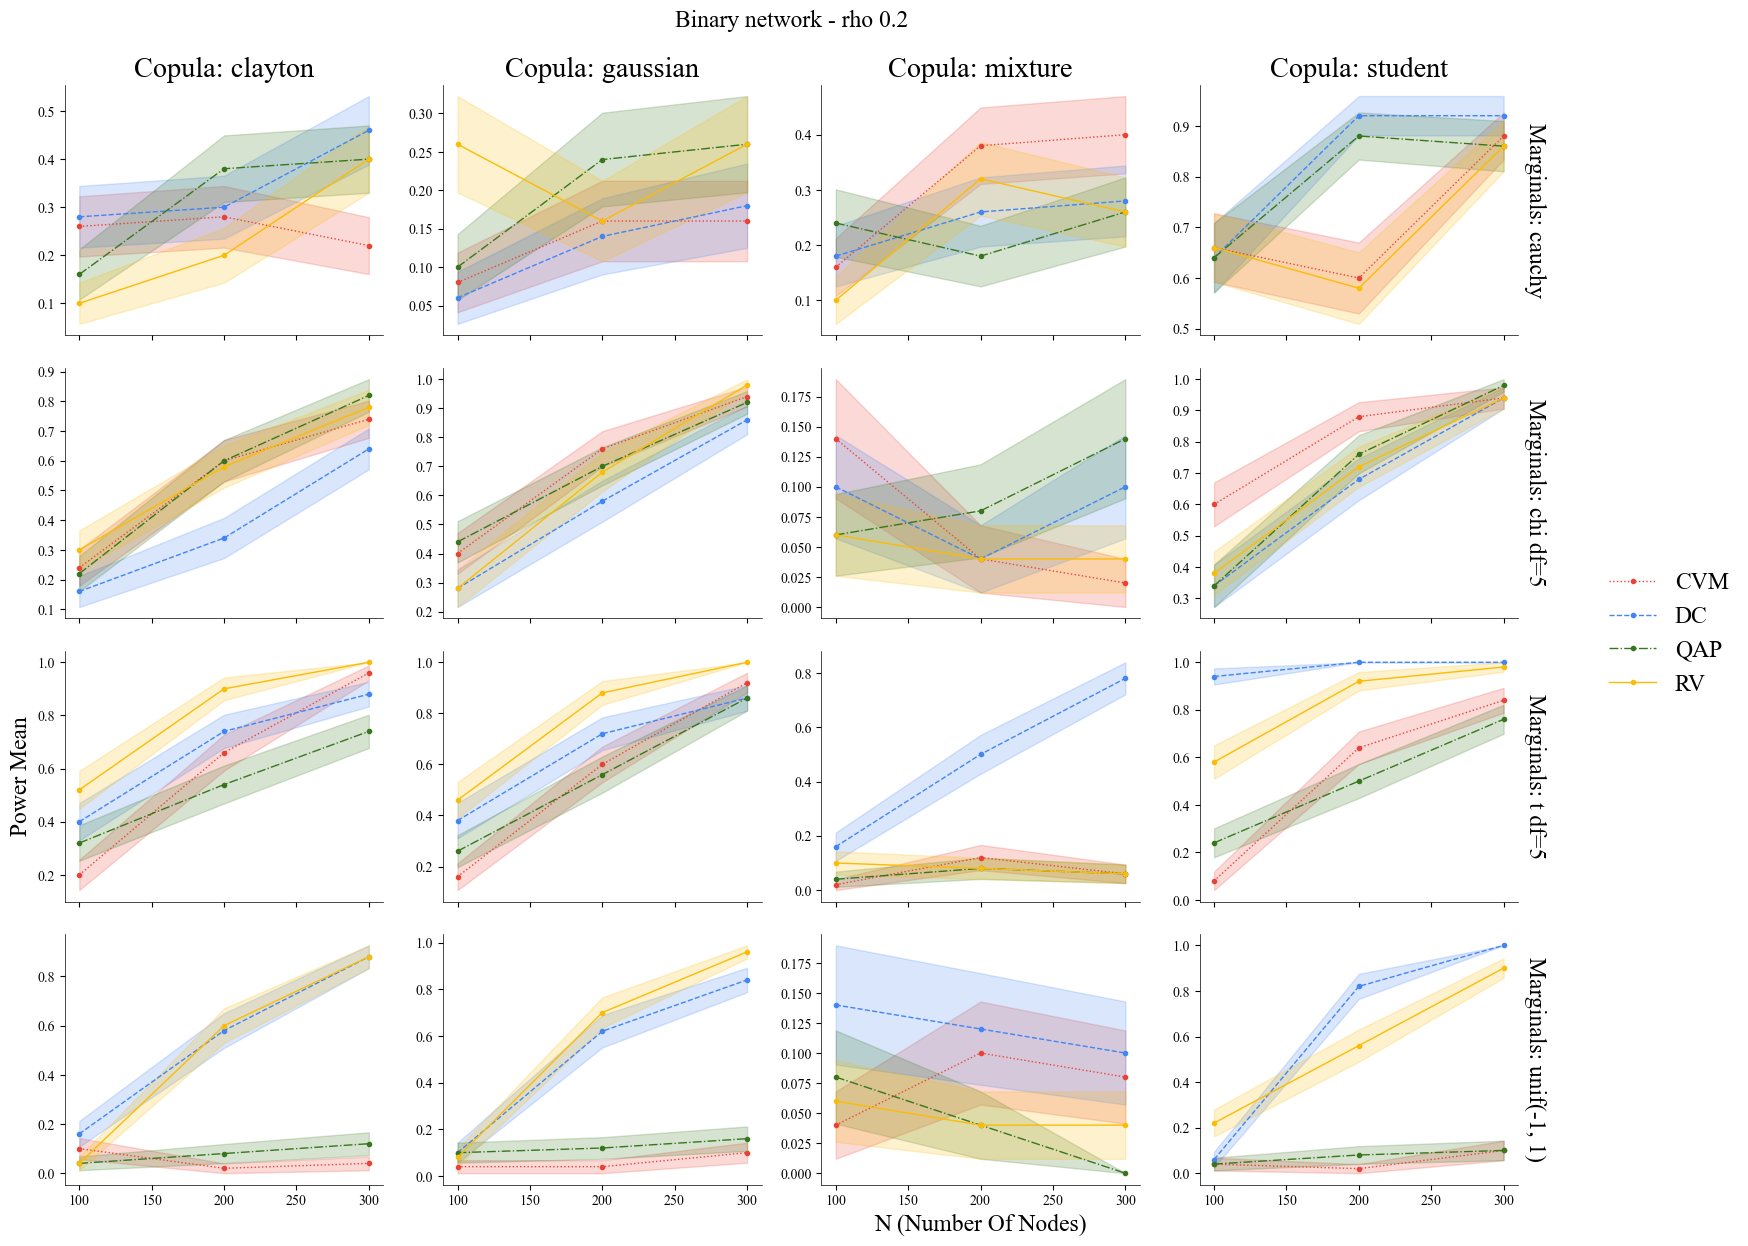

In [ ]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp["copula"].isin(["gumbel"])]
temp = temp[~temp["marginals"].isin(["gaussian", "uniform -1 1"])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
    name_conversion={"n": "n (Number of nodes)"},
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Weighted network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)'},
#     save_path="figures/binary_network_rho_0_2_heavy_tails"
# )

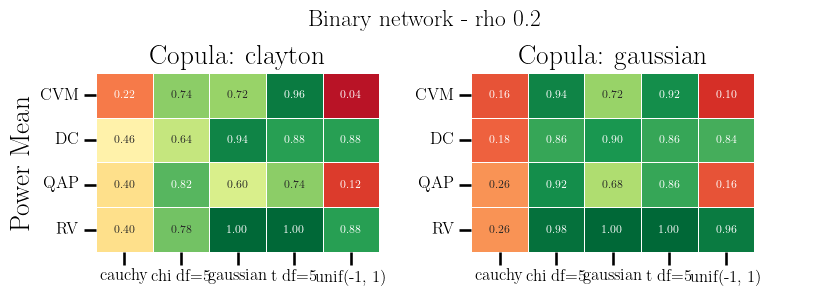

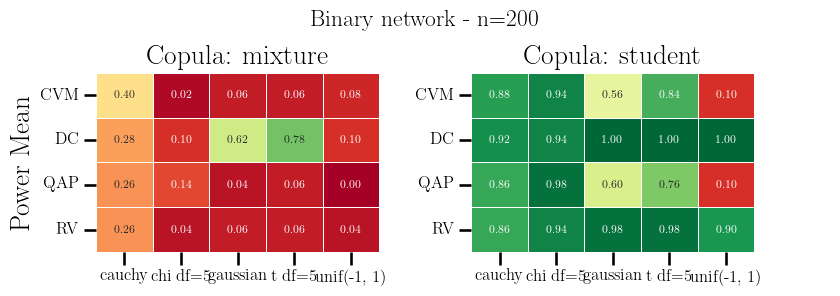

In [ ]:
# small tail
import seaborn as sns

sns.set_context("talk", font_scale=1.1)

custom_params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}
plt.rcParams.update(custom_params)

temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp["copula"].isin(["gumbel"])]
temp = temp[temp["n"] == 300]
temp.iloc[:, temp.columns.get_loc("method")] = temp["method"].replace(
    {"DistanceCorrelation": "DC", "ObservedCVM": "CVM", "RVPermutationTest": "RV"}
)

plot_grid(
    grouped_stats=temp[temp["copula"].isin(["clayton", "gaussian"])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
    name_conversion={"n": "n (Number of nodes)", "marginals": ""},
    show_row_names=False,
)

plot_grid(
    grouped_stats=temp[~temp["copula"].isin(["clayton", "gaussian"])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - n=200",
    name_conversion={"n": "n (Number of nodes)", "marginals": ""},
    show_row_names=False,
)

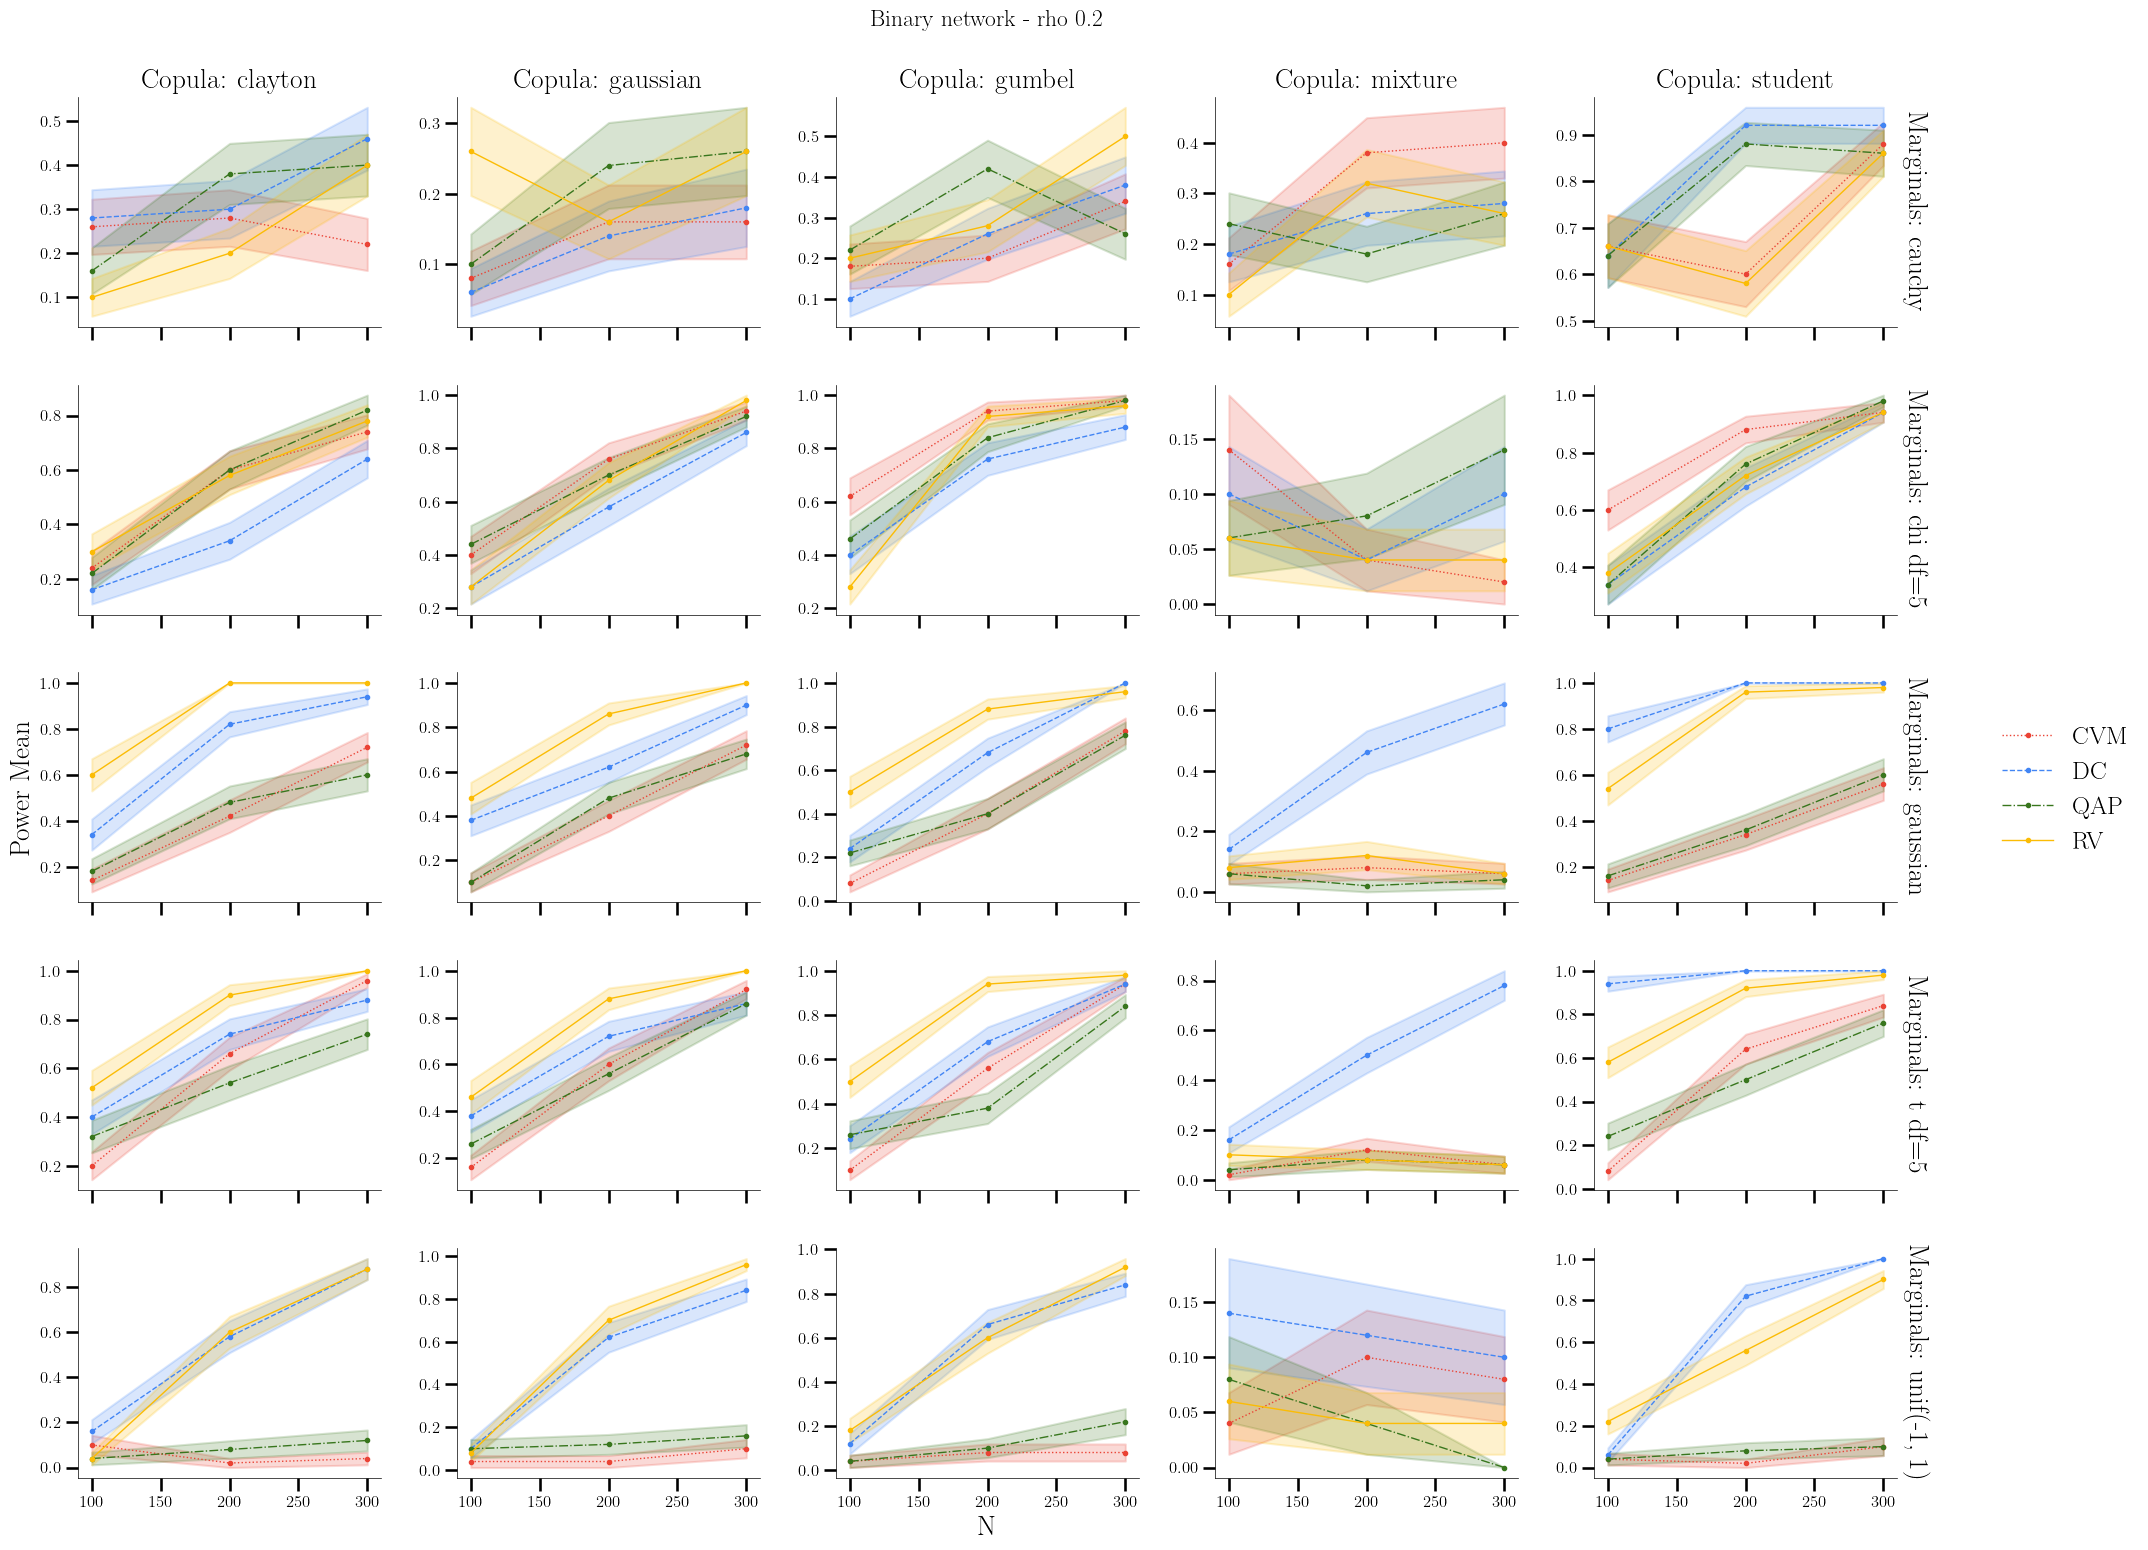

In [ ]:
temp = agg_alt_02_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
)

flipping


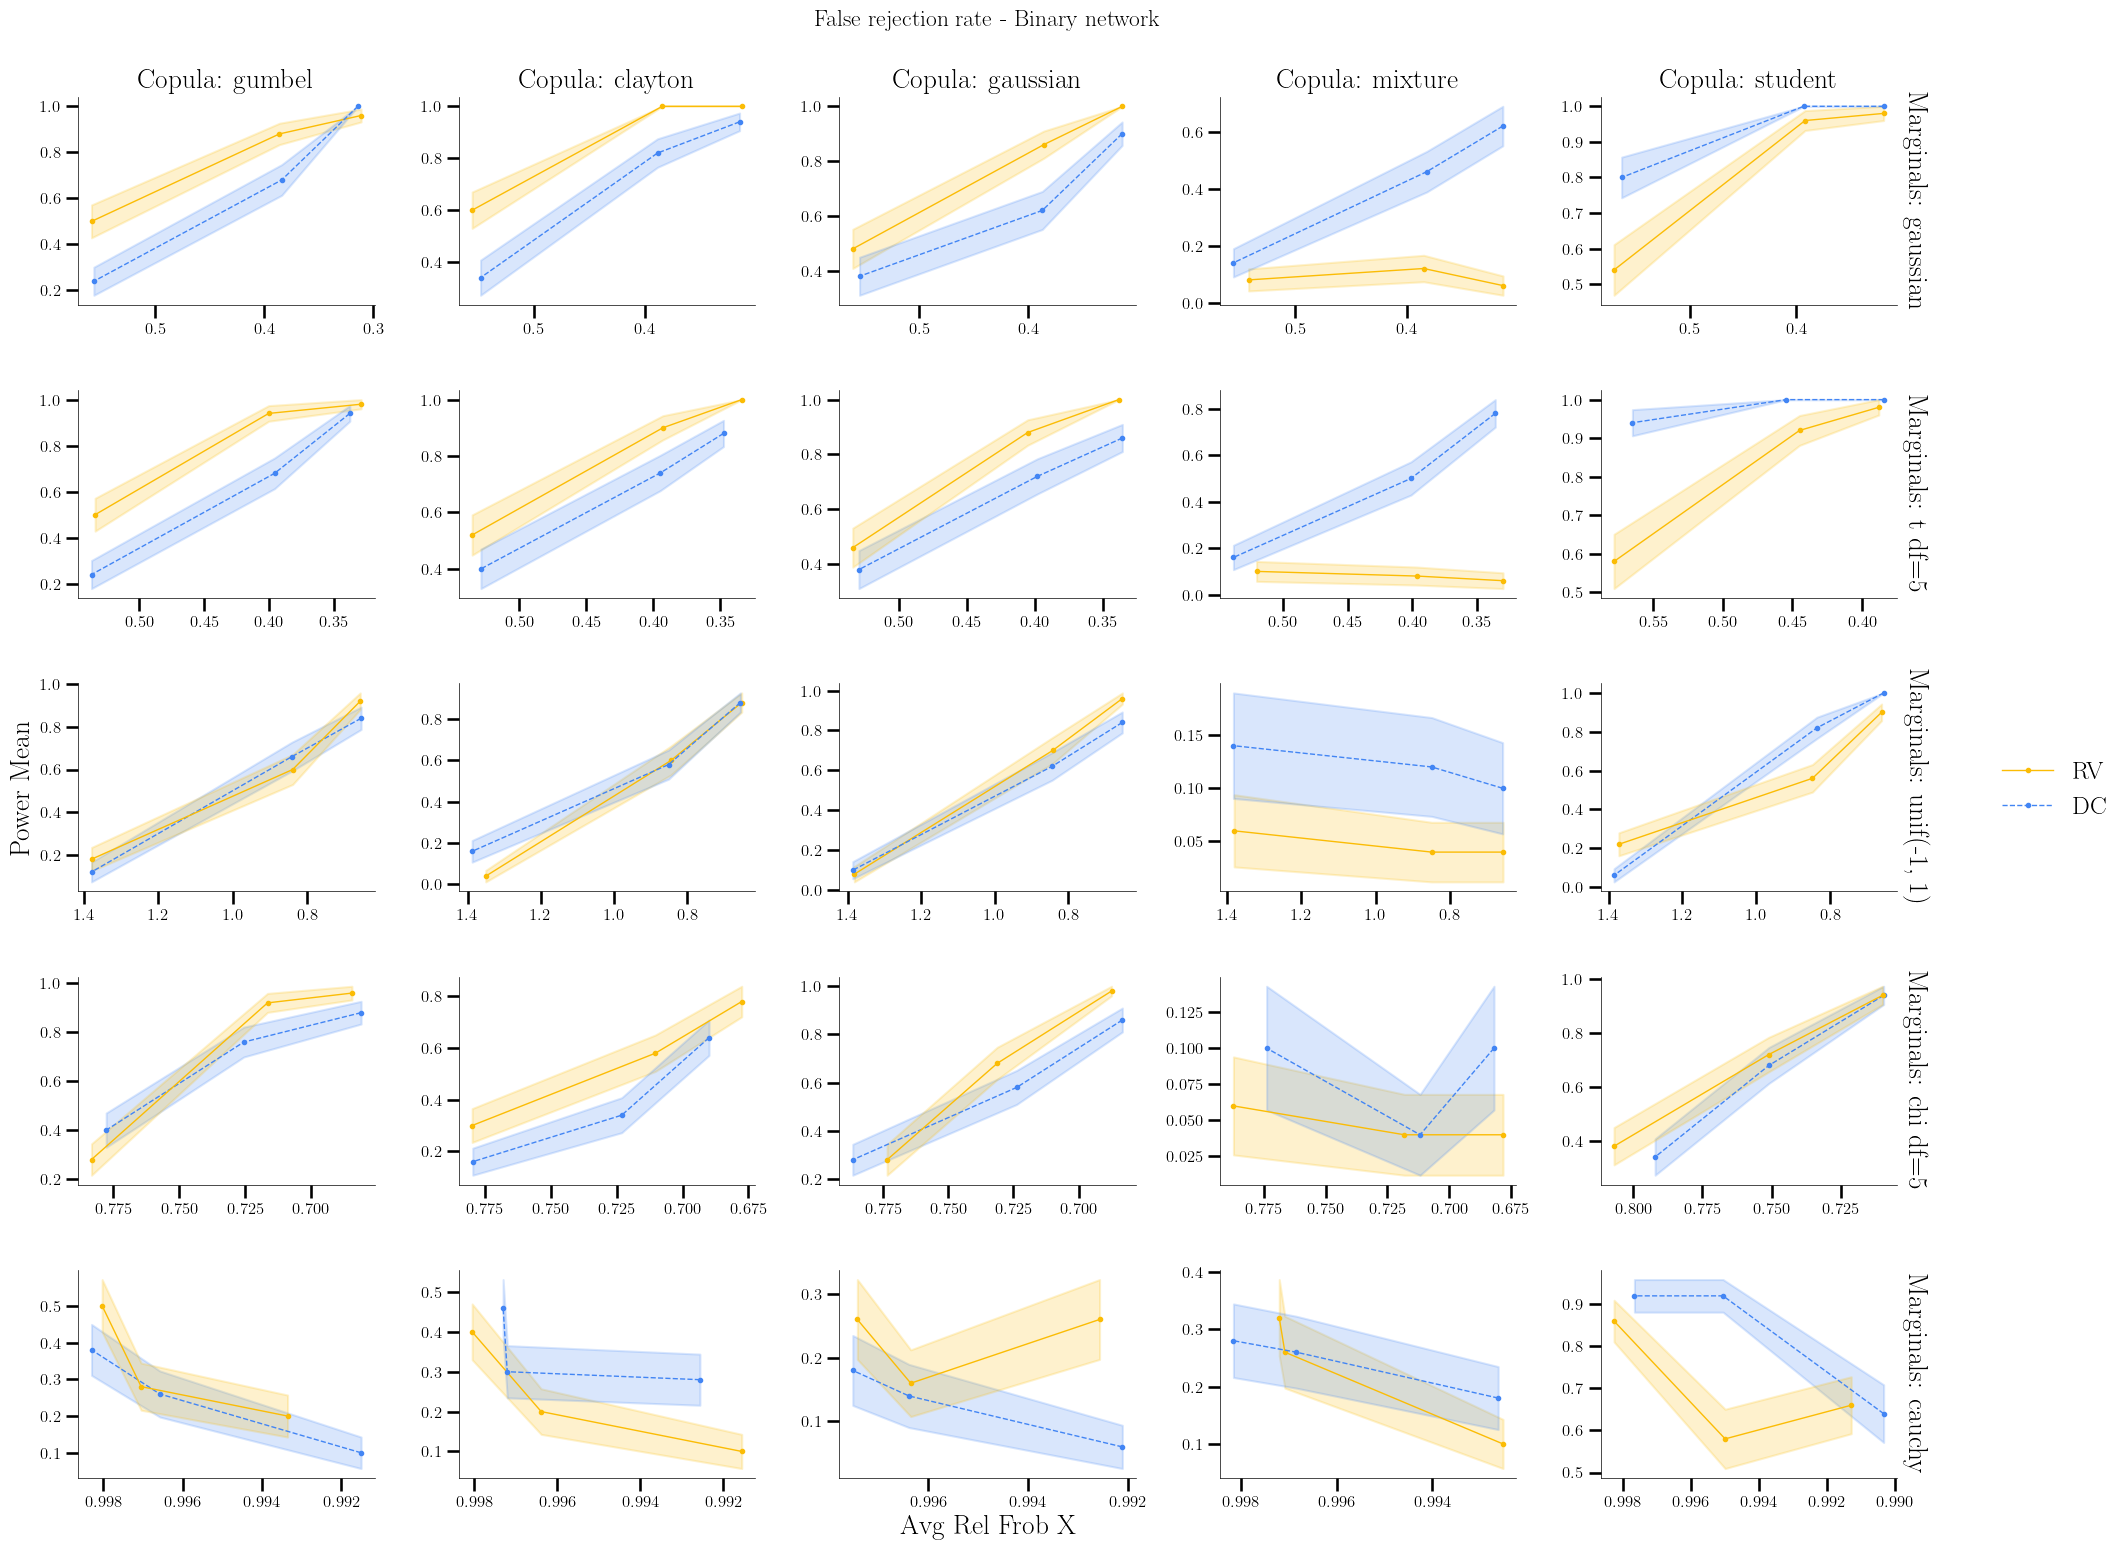

In [ ]:
temp = agg_alt_02_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Binary network",
    flip_x_axis=True,
)